# Traveling Salesman Problem — Brazil58 Dataset
## Complete Comparison: All 4 Algorithms

| # | Category | Algorithm | Seed / Init |
|---|----------|-----------|-------------|
| 1 | **Greedy** | Cheapest Link (Greedy Edge) | — |
| 2 | **Local Search** | Relocate | Cheapest Link |
| 3 | **Greedy** | Nearest Neighbor (Additional Edge) | — |
| 4 | **Local Search** | 2-Opt | Nearest Neighbor |

**Dataset:** brazil58 — 58 cities in Brazil (Ferreira)  
**Distance type:** Explicit upper-row symmetric matrix  
**Validation:** Every tour is checked for correctness (no sub-tours, no skipped cities, no duplicates).

---


## 1. Imports & Setup

In [1]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.manifold import MDS



## 2. Data Loading — Brazil58 TSP

The distance matrix is stored in **UPPER_ROW** format:  
Row `i` (0-indexed) contains distances from city `i` to cities `i+1, i+2, ..., n-1`.


In [2]:
def parse_upper_row_matrix(filepath: str) -> np.ndarray:
    """
    Parse a .tsp file with UPPER_ROW edge weight format into a full
    symmetric distance matrix.
    """
    with open(filepath, 'r') as f:
        content = f.read()

    lines = content.splitlines()
    dimension = None
    for line in lines:
        if line.strip().startswith('DIMENSION'):
            dimension = int(line.split(':')[1].strip())
            break

    section_start = content.find('EDGE_WEIGHT_SECTION')
    raw_section = content[section_start:].replace('EDGE_WEIGHT_SECTION', '')
    raw_section = raw_section.replace('EOF', '').strip()
    values = list(map(int, raw_section.split()))

    n = dimension
    dist = np.zeros((n, n), dtype=int)
    idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            dist[i][j] = values[idx]
            dist[j][i] = values[idx]
            idx += 1

    return dist


FILEPATH = "data/brazil58.tsp"
dist_matrix = parse_upper_row_matrix(FILEPATH)
N = dist_matrix.shape[0]

print(f"Dataset loaded: brazil58")
print(f"Number of cities (N): {N}")
print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Sample distances (city 0 → cities 1..5): {dist_matrix[0, 1:6]}")


Dataset loaded: brazil58
Number of cities (N): 58
Distance matrix shape: (58, 58)
Sample distances (city 0 → cities 1..5): [2635 2713 2437 1600 2845]


## 3. Utility Functions

In [3]:
def tour_length(tour: list, dist: np.ndarray) -> int:
    """Total distance of a closed tour."""
    n = len(tour)
    return sum(int(dist[tour[i]][tour[(i + 1) % n]]) for i in range(n))


def is_valid_tour(tour: list, n: int) -> bool:
    """True if tour is a valid Hamiltonian circuit."""
    return len(tour) == n and set(tour) == set(range(n))


def validate_tour(label: str, tour: list, n: int) -> None:
    """Print a full integrity report for a tour."""
    errors = []
    if len(tour) != n:
        errors.append(f"Length mismatch: expected {n}, got {len(tour)}")
    if len(set(tour)) != len(tour):
        duplicates = {c for c in tour if tour.count(c) > 1}
        errors.append(f"Duplicate cities: {duplicates}")
    missing = set(range(n)) - set(tour)
    if missing:
        errors.append(f"Missing cities: {missing}")
    print(f"[{label}]")
    if not errors:
        print(f"  ✓ Valid — {n} cities, no duplicates, no missing cities.")
    else:
        for e in errors:
            print(f"  ✗ {e}")
    print()


def print_result(label: str, tour: list, dist: np.ndarray, elapsed_ms: float) -> None:
    """Pretty-print algorithm result."""
    length = tour_length(tour, dist)
    valid  = is_valid_tour(tour, dist.shape[0])
    print(f"{'='*65}")
    print(f"  {label}")
    print(f"{'='*65}")
    print(f"  Total distance : {length:,}")
    print(f"  Runtime        : {elapsed_ms:.3f} ms")
    print(f"  Valid tour     : {valid}")
    print(f"  Tour (1-indexed, first 20 cities shown):")
    t1 = [c + 1 for c in tour]
    print(f"    {' → '.join(map(str, t1[:20]))} → ...")
    print(f"{'='*65}\n")


print("Utility functions defined.")


Utility functions defined.


## 4. Greedy Algorithm 1 — Cheapest Link (Greedy Edge)

**Strategy:**  
Sort all edges by weight (ascending). Add each edge to the tour only when:
1. Neither endpoint already has degree 2
2. Adding it does **not** form a premature sub-cycle (Union-Find check)

The final edge closes the Hamiltonian circuit.

**Complexity:** O(n² log n) — dominated by sorting all edges.


In [4]:
def _find_root(parent: list, x: int) -> int:
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def _union(parent: list, rank: list, a: int, b: int) -> None:
    ra, rb = _find_root(parent, a), _find_root(parent, b)
    if ra == rb:
        return
    if rank[ra] < rank[rb]:
        ra, rb = rb, ra
    parent[rb] = ra
    if rank[ra] == rank[rb]:
        rank[ra] += 1

def cheapest_link(dist: np.ndarray) -> list:
    """
    Greedy Cheapest-Link: build a Hamiltonian circuit by adding
    the shortest valid edge at each step.
    """
    n = dist.shape[0]
    edges = sorted((dist[i][j], i, j) for i in range(n) for j in range(i+1, n))

    degree    = [0] * n
    adj       = [[] for _ in range(n)]
    parent    = list(range(n))
    rank_uf   = [0] * n
    edge_count = 0

    for weight, u, v in edges:
        if edge_count == n:
            break
        if degree[u] >= 2 or degree[v] >= 2:
            continue
        forms_cycle  = (_find_root(parent, u) == _find_root(parent, v))
        is_last_edge = (edge_count == n - 1)
        if forms_cycle and not is_last_edge:
            continue
        adj[u].append(v)
        adj[v].append(u)
        degree[u] += 1
        degree[v] += 1
        _union(parent, rank_uf, u, v)
        edge_count += 1

    # Reconstruct ordered tour from adjacency list
    visited = [False] * n
    tour, prev, current = [0], -1, 0
    visited[0] = True
    for _ in range(n - 1):
        for nxt in adj[current]:
            if nxt != prev:
                tour.append(nxt)
                visited[nxt] = True
                prev, current = current, nxt
                break

    return tour


t0 = time.perf_counter()
cl_tour = cheapest_link(dist_matrix)
cl_time_ms = (time.perf_counter() - t0) * 1000

print_result("Cheapest Link (Greedy Edge)", cl_tour, dist_matrix, cl_time_ms)


  Cheapest Link (Greedy Edge)
  Total distance : 30,458
  Runtime        : 5.570 ms
  Valid tour     : True
  Tour (1-indexed, first 20 cities shown):
    1 → 30 → 13 → 40 → 25 → 9 → 32 → 20 → 53 → 50 → 4 → 56 → 46 → 34 → 37 → 14 → 33 → 45 → 15 → 7 → ...



## 5. Local Search 1 — Relocate *(initialized by Cheapest Link)*

**Strategy:**  
For each city `tour[i]`, compute the gain from removing it and re-inserting it at every other position `j`.  
Accept the best improving move, then restart the scan.  
Stop when a full pass finds no improvement → **local optimum**.

**Complexity:** O(n²) per iteration.


In [5]:
def relocate(initial_tour: list, dist: np.ndarray) -> tuple:
    """
    Relocate local search: move individual cities to cheaper positions.
    Returns (improved_tour, number_of_improving_moves).
    """
    tour = list(initial_tour)
    n = len(tour)
    improved = True
    iterations = 0

    while improved:
        improved = False
        for i in range(n):
            city_i = tour[i]
            prev_i = tour[(i - 1) % n]
            next_i = tour[(i + 1) % n]
            # Cost saved by removing city_i
            removal_gain = (dist[prev_i][city_i] + dist[city_i][next_i]
                            - dist[prev_i][next_i])

            best_delta, best_k = 0, -1
            for k in range(n):
                if k == i or k == (i - 1) % n:
                    continue
                city_k = tour[k]
                next_k = tour[(k + 1) % n]
                ins_cost = (dist[city_k][city_i] + dist[city_i][next_k]
                            - dist[city_k][next_k])
                delta = ins_cost - removal_gain   # net change (negative = improvement)
                if delta < best_delta:
                    best_delta, best_k = delta, k

            if best_k != -1:
                target_city = tour[best_k]
                city = tour.pop(i)
                new_idx = tour.index(target_city)
                tour.insert(new_idx + 1, city)
                improved = True
                iterations += 1
                break

    return tour, iterations


t0 = time.perf_counter()
rel_tour, rel_iters = relocate(cl_tour, dist_matrix)
rel_time_ms = (time.perf_counter() - t0) * 1000

print_result("Relocate Local Search (init: Cheapest Link)", rel_tour, dist_matrix, rel_time_ms)
print(f"  Improving moves: {rel_iters}")


  Relocate Local Search (init: Cheapest Link)
  Total distance : 26,789
  Runtime        : 93.622 ms
  Valid tour     : True
  Tour (1-indexed, first 20 cities shown):
    1 → 30 → 13 → 40 → 25 → 9 → 32 → 20 → 53 → 50 → 4 → 22 → 8 → 55 → 54 → 2 → 41 → 48 → 29 → 33 → ...

  Improving moves: 19


## 6. Greedy Algorithm 2 — Nearest Neighbor (Additional Edge)

**Strategy:**  
Starting from city 0, always extend the current path to the **nearest unvisited city**.  
When all cities are visited, close the circuit back to city 0.

**Complexity:** O(n²)


In [6]:
def nearest_neighbor(dist: np.ndarray, start: int = 0) -> list:
    """
    Nearest Neighbor greedy algorithm for TSP.
    Builds a Hamiltonian circuit by always extending to the
    closest unvisited city (Additional Edge strategy).
    """
    n = dist.shape[0]
    visited = [False] * n
    tour = [start]
    visited[start] = True

    for _ in range(n - 1):
        current   = tour[-1]
        best_next = -1
        best_dist = math.inf
        for city in range(n):
            if not visited[city] and dist[current][city] < best_dist:
                best_dist = dist[current][city]
                best_next = city
        visited[best_next] = True
        tour.append(best_next)

    return tour


t0 = time.perf_counter()
nn_tour = nearest_neighbor(dist_matrix, start=0)
nn_time_ms = (time.perf_counter() - t0) * 1000

print_result("Nearest Neighbor (Additional Edge)", nn_tour, dist_matrix, nn_time_ms)


  Nearest Neighbor (Additional Edge)
  Total distance : 30,774
  Runtime        : 1.702 ms
  Valid tour     : True
  Tour (1-indexed, first 20 cities shown):
    1 → 30 → 13 → 40 → 25 → 9 → 32 → 20 → 53 → 50 → 4 → 18 → 44 → 24 → 58 → 5 → 27 → 43 → 12 → 57 → ...



## 7. Local Search 2 — 2-Opt *(initialized by Nearest Neighbor)*

**Strategy:**  
For every pair of non-adjacent edges `(a→b)` and `(c→d)`, check if replacing them with  
`(a→c)` and `(b→d)` — i.e. reversing the segment between `b` and `c` — reduces total distance.  
Apply the improvement immediately and restart. Stop when no improving swap exists.

**Complexity:** O(n²) per iteration.


In [7]:
def two_opt(initial_tour: list, dist: np.ndarray) -> tuple:
    """
    2-Opt local search to improve a TSP tour.
    Repeatedly scans all edge pairs and reverses improving sub-segments.
    Returns (improved_tour, number_of_improving_swaps).
    """
    tour = list(initial_tour)
    n = len(tour)
    improved = True
    iterations = 0

    while improved:
        improved = False
        for i in range(n - 1):
            for j in range(i + 2, n):
                if i == 0 and j == n - 1:
                    continue   # same tour, skip wrap-around
                a, b = tour[i],     tour[i + 1]
                c, d = tour[j],     tour[(j + 1) % n]
                delta = (dist[a][b] + dist[c][d]) - (dist[a][c] + dist[b][d])
                if delta > 0:   # improvement found
                    tour[i + 1:j + 1] = tour[i + 1:j + 1][::-1]
                    improved = True
                    iterations += 1
                    break
            if improved:
                break

    return tour, iterations


t0 = time.perf_counter()
opt_tour, opt_iters = two_opt(nn_tour, dist_matrix)
opt_time_ms = (time.perf_counter() - t0) * 1000

print_result("2-Opt Local Search (init: Nearest Neighbor)", opt_tour, dist_matrix, opt_time_ms)
print(f"  Improving swaps: {opt_iters}")


  2-Opt Local Search (init: Nearest Neighbor)
  Total distance : 26,008
  Runtime        : 44.622 ms
  Valid tour     : True
  Tour (1-indexed, first 20 cities shown):
    1 → 30 → 13 → 40 → 25 → 9 → 32 → 20 → 53 → 50 → 4 → 8 → 22 → 42 → 31 → 7 → 38 → 16 → 11 → 39 → ...

  Improving swaps: 14


## 8. Tour Validation — Integrity Check

In [8]:
print("=" * 50)
print("  TOUR VALIDATION")
print("=" * 50)
validate_tour("Cheapest Link",                    cl_tour,  N)
validate_tour("Relocate (init: Cheapest Link)",   rel_tour, N)
validate_tour("Nearest Neighbor",                 nn_tour,  N)
validate_tour("2-Opt (init: Nearest Neighbor)",   opt_tour, N)


  TOUR VALIDATION
[Cheapest Link]
  ✓ Valid — 58 cities, no duplicates, no missing cities.

[Relocate (init: Cheapest Link)]
  ✓ Valid — 58 cities, no duplicates, no missing cities.

[Nearest Neighbor]
  ✓ Valid — 58 cities, no duplicates, no missing cities.

[2-Opt (init: Nearest Neighbor)]
  ✓ Valid — 58 cities, no duplicates, no missing cities.



## 9. Within-Pair Comparison

Each greedy algorithm paired with its local search improvement.


In [9]:
cl_len  = tour_length(cl_tour,  dist_matrix)
rel_len = tour_length(rel_tour, dist_matrix)
nn_len  = tour_length(nn_tour,  dist_matrix)
opt_len = tour_length(opt_tour, dist_matrix)

print("─" * 70)
print("  PAIR A — Cheapest Link  →  Relocate")
print("─" * 70)
imp_a = (cl_len - rel_len) / cl_len * 100
print(f"  Cheapest Link  : {cl_len:>10,}   ({cl_time_ms:.3f} ms)")
print(f"  Relocate       : {rel_len:>10,}   ({rel_time_ms:.3f} ms)   Δ = -{cl_len - rel_len:,} ({imp_a:.2f}%)")
print(f"  Relocate moves : {rel_iters}")

print()
print("─" * 70)
print("  PAIR B — Nearest Neighbor  →  2-Opt")
print("─" * 70)
imp_b = (nn_len - opt_len) / nn_len * 100
print(f"  Nearest Neighbor : {nn_len:>10,}   ({nn_time_ms:.3f} ms)")
print(f"  2-Opt            : {opt_len:>10,}   ({opt_time_ms:.3f} ms)   Δ = -{nn_len - opt_len:,} ({imp_b:.2f}%)")
print(f"  2-Opt swaps      : {opt_iters}")


──────────────────────────────────────────────────────────────────────
  PAIR A — Cheapest Link  →  Relocate
──────────────────────────────────────────────────────────────────────
  Cheapest Link  :     30,458   (5.570 ms)
  Relocate       :     26,789   (93.622 ms)   Δ = -3,669 (12.05%)
  Relocate moves : 19

──────────────────────────────────────────────────────────────────────
  PAIR B — Nearest Neighbor  →  2-Opt
──────────────────────────────────────────────────────────────────────
  Nearest Neighbor :     30,774   (1.702 ms)
  2-Opt            :     26,008   (44.622 ms)   Δ = -4,766 (15.49%)
  2-Opt swaps      : 14


## 10. Cross-Algorithm Comparison (All 4)

Full ranking across both greedy and both local search results.


In [10]:
all_results = [
    ("Cheapest Link",                   "Greedy",       cl_len,  cl_time_ms,  None),
    ("Relocate  (init: Cheapest Link)", "Local Search", rel_len, rel_time_ms, rel_iters),
    ("Nearest Neighbor",                "Greedy",       nn_len,  nn_time_ms,  None),
    ("2-Opt     (init: Nearest Neigh)", "Local Search", opt_len, opt_time_ms, opt_iters),
]

best_dist = min(r[2] for r in all_results)
best_time = min(r[3] for r in all_results)

HDR = f"  {'Algorithm':<36} {'Type':<14} {'Distance':>10}  {'Time(ms)':>9}  {'vs Best':>8}  {'LS Moves':>9}"
SEP = "─" * len(HDR)
print(SEP)
print(HDR)
print(SEP)
for name, typ, dist_val, t_ms, iters in all_results:
    star = "★" if dist_val == best_dist else " "
    gap  = (dist_val - best_dist) / best_dist * 100
    it   = str(iters) if iters is not None else "—"
    print(f"  {star} {name:<34} {typ:<14} {dist_val:>10,}  {t_ms:>9.3f}  {gap:>+7.2f}%  {it:>9}")
print(SEP)
print(f"\n  ★ Best distance: {best_dist:,}")


────────────────────────────────────────────────────────────────────────────────────────────────
  Algorithm                            Type             Distance   Time(ms)   vs Best   LS Moves
────────────────────────────────────────────────────────────────────────────────────────────────
    Cheapest Link                      Greedy             30,458      5.570   +17.11%          —
    Relocate  (init: Cheapest Link)    Local Search       26,789     93.622    +3.00%         19
    Nearest Neighbor                   Greedy             30,774      1.702   +18.33%          —
  ★ 2-Opt     (init: Nearest Neigh)    Local Search       26,008     44.622    +0.00%         14
────────────────────────────────────────────────────────────────────────────────────────────────

  ★ Best distance: 26,008


## 11. Visualization

In [11]:
# Compute MDS layout once (shared by all plots)
mds    = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(dist_matrix.astype(float))
print(f"MDS layout computed — shape: {coords.shape}")


MDS layout computed — shape: (58, 2)


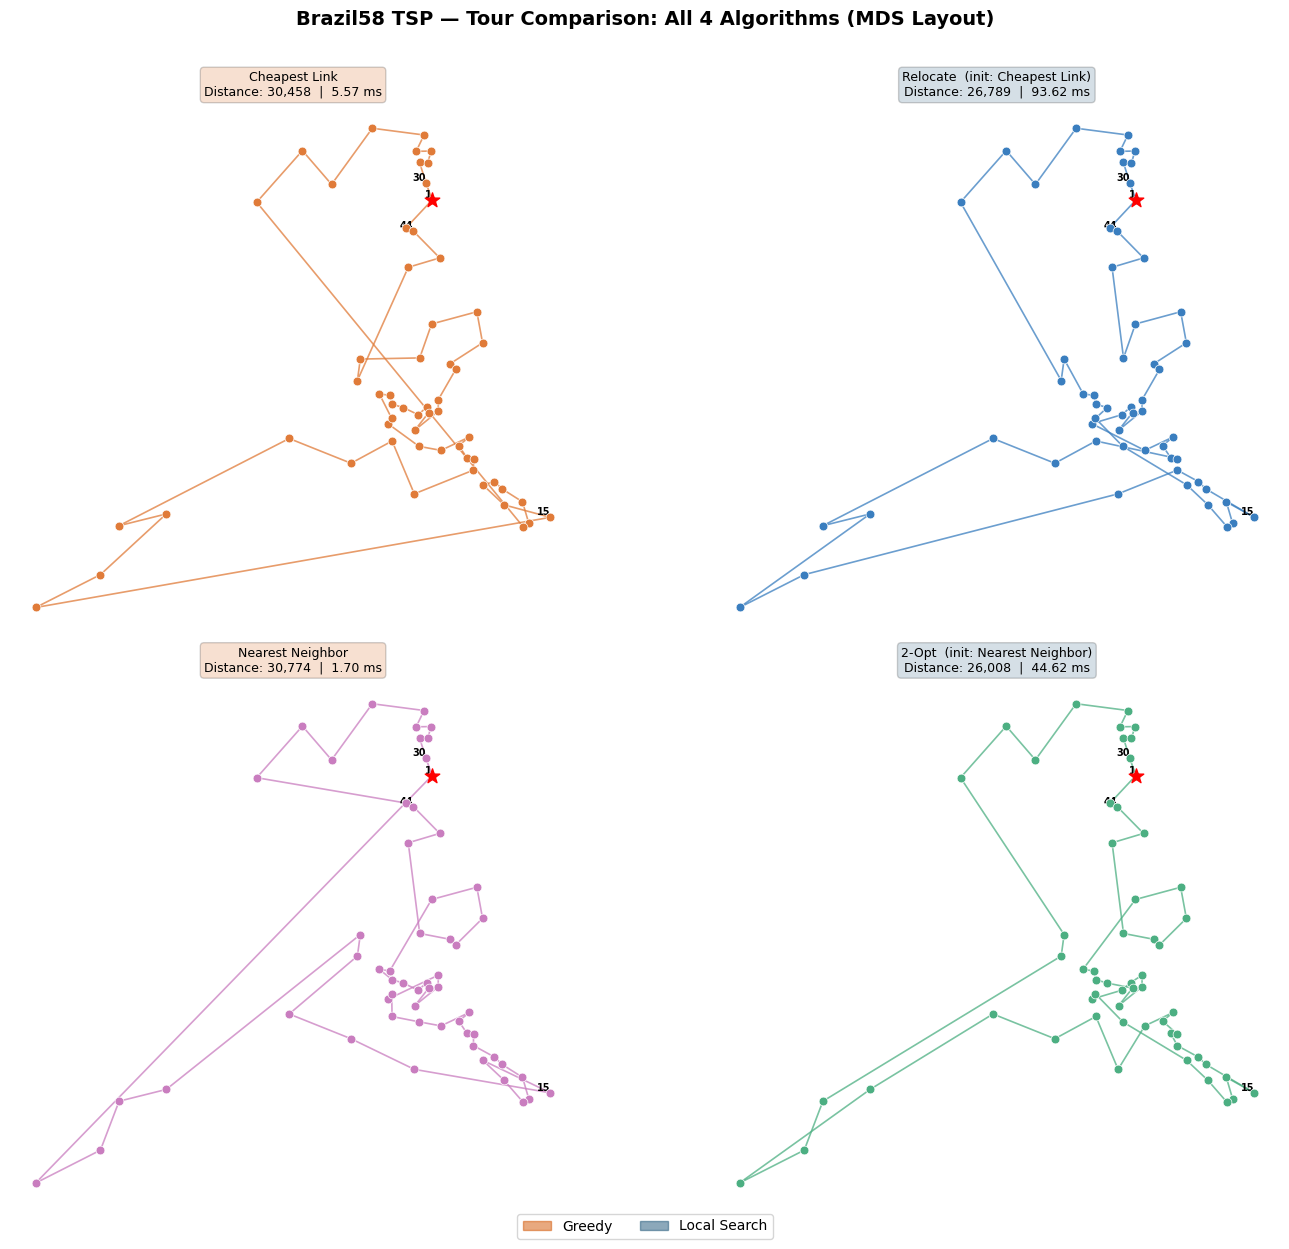

Saved -> tours_all4.png


In [12]:
ALGO_DATA = [
    ("Cheapest Link",                   cl_tour,  cl_len,  cl_time_ms,  "#e07b39", "Greedy"),
    ("Relocate  (init: Cheapest Link)", rel_tour, rel_len, rel_time_ms, "#3a7ebf", "Local Search"),
    ("Nearest Neighbor",                nn_tour,  nn_len,  nn_time_ms,  "#c97dbf", "Greedy"),
    ("2-Opt  (init: Nearest Neighbor)", opt_tour, opt_len, opt_time_ms, "#4caf82", "Local Search"),
]

def draw_tour(ax, tour, coords, title, color, total_dist, t_ms, alg_type):
    n = len(tour)
    for k in range(n):
        u, v = tour[k], tour[(k + 1) % n]
        ax.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]],
                '-', color=color, linewidth=1.2, alpha=0.75)
    ax.scatter(coords[:,0], coords[:,1], s=40, color=color,
               zorder=5, edgecolors='white', linewidths=0.5)
    ax.scatter([coords[tour[0],0]], [coords[tour[0],1]],
               s=120, color='red', zorder=6, marker='*')
    for city in [0, n//4, n//2, 3*n//4]:
        ax.text(coords[city,0], coords[city,1], str(city+1),
                fontsize=7, fontweight='bold', color='black', ha='right', va='bottom')
    type_color = "#d35400" if alg_type == "Greedy" else "#1a5276"
    subtitle = "Distance: {:,}  |  {:.2f} ms".format(total_dist, t_ms)
    ax.set_title(title + "\n" + subtitle, fontsize=9, pad=6,
                 bbox=dict(boxstyle='round,pad=0.3', fc=type_color, alpha=0.18))
    ax.set_aspect('equal')
    ax.axis('off')


fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Brazil58 TSP — Tour Comparison: All 4 Algorithms (MDS Layout)",
             fontsize=14, fontweight='bold', y=1.01)

for ax, (title, tour, dist_val, t_ms, color, typ) in zip(axes.flat, ALGO_DATA):
    draw_tour(ax, tour, coords, title, color, dist_val, t_ms, typ)

g_patch  = mpatches.Patch(color='#d35400', alpha=0.5, label='Greedy')
ls_patch = mpatches.Patch(color='#1a5276', alpha=0.5, label='Local Search')
fig.legend(handles=[g_patch, ls_patch], loc='lower center',
           ncol=2, fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("tours_all4.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> tours_all4.png")


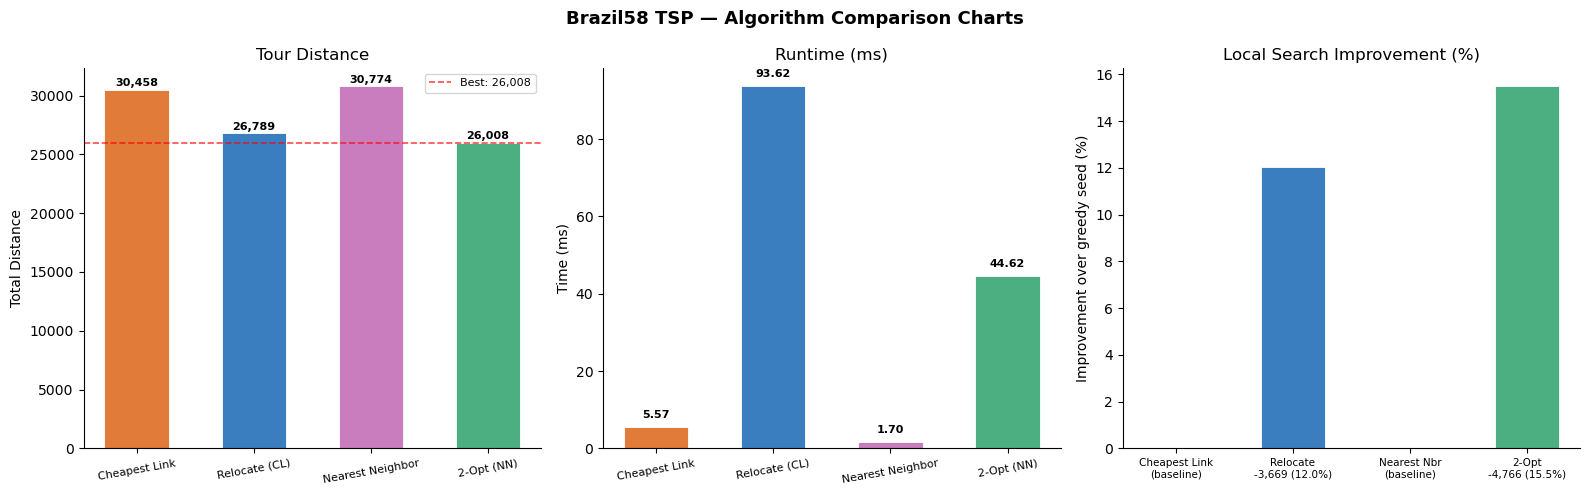

Saved -> comparison_charts.png


In [13]:
labels = ["Cheapest Link", "Relocate (CL)", "Nearest Neighbor", "2-Opt (NN)"]
dists  = [cl_len, rel_len, nn_len, opt_len]
times  = [cl_time_ms, rel_time_ms, nn_time_ms, opt_time_ms]
colors = ["#e07b39", "#3a7ebf", "#c97dbf", "#4caf82"]

best_d = min(dists)
x      = np.arange(len(labels))
w      = 0.55

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Brazil58 TSP — Algorithm Comparison Charts", fontsize=13, fontweight='bold')

# Chart 1: Distance
ax1 = axes[0]
bars = ax1.bar(x, dists, w, color=colors, edgecolor='white', linewidth=0.6)
ax1.axhline(best_d, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
            label='Best: {:,}'.format(best_d))
for bar, val in zip(bars, dists):
    ax1.text(bar.get_x() + bar.get_width()/2, val + max(dists)*0.005,
             '{:,}'.format(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8, rotation=10)
ax1.set_ylabel('Total Distance'); ax1.set_title('Tour Distance')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Chart 2: Runtime
ax2 = axes[1]
bars2 = ax2.bar(x, times, w, color=colors, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width()/2, val + max(times)*0.02,
             '{:.2f}'.format(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8, rotation=10)
ax2.set_ylabel('Time (ms)'); ax2.set_title('Runtime (ms)')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Chart 3: % improvement over greedy seed
ax3 = axes[2]
imp_a = (cl_len - rel_len) / cl_len * 100
imp_b = (nn_len - opt_len) / nn_len * 100
improvements = [0, imp_a, 0, imp_b]
bl = [
    "Cheapest Link\n(baseline)",
    "Relocate\n-{:,} ({:.1f}%)".format(cl_len - rel_len, imp_a),
    "Nearest Nbr\n(baseline)",
    "2-Opt\n-{:,} ({:.1f}%)".format(nn_len - opt_len, imp_b),
]
bars3 = ax3.bar(x, improvements, w, color=colors, edgecolor='white', linewidth=0.6)
ax3.set_xticks(x); ax3.set_xticklabels(bl, fontsize=7.5)
ax3.set_ylabel('Improvement over greedy seed (%)')
ax3.set_title('Local Search Improvement (%)')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> comparison_charts.png")


## 12. Final Results Summary

In [14]:
best_d = min(cl_len, rel_len, nn_len, opt_len)

def star(v): return "★" if v == best_d else " "

W = 67
print("╔" + "═"*W + "╗")
print("║" + "  FINAL RESULTS — BRAZIL58 TSP (58 cities)".center(W) + "║")
print("╠" + "═"*W + "╣")
print(f"║  {'Algorithm':<36} {'Distance':>9}  {'Time(ms)':>9}  {'vs Best':>7}  ║")
print("╠" + "═"*W + "╣")
rows = [
    ("Cheapest Link  (Greedy)",           cl_len,  cl_time_ms),
    ("Relocate       (Local Search)",     rel_len, rel_time_ms),
    ("Nearest Neighbor  (Greedy)",        nn_len,  nn_time_ms),
    ("2-Opt          (Local Search)",     opt_len, opt_time_ms),
]
for name, d, t in rows:
    gap = (d - best_d) / best_d * 100
    s   = star(d)
    print(f"║ {s} {name:<36} {d:>9,}  {t:>9.3f}  {gap:>+6.2f}%  ║")
print("╠" + "═"*W + "╣")
print(f"║  Best solution : {best_d:,} (★)".ljust(W+1) + "║")
print(f"║  Pair A improvement (Relocate over CL) : {(cl_len-rel_len)/cl_len*100:.2f}%".ljust(W+1) + "║")
print(f"║  Pair B improvement (2-Opt over NN)    : {(nn_len-opt_len)/nn_len*100:.2f}%".ljust(W+1) + "║")
print("╚" + "═"*W + "╝")


╔═══════════════════════════════════════════════════════════════════╗
║               FINAL RESULTS — BRAZIL58 TSP (58 cities)            ║
╠═══════════════════════════════════════════════════════════════════╣
║  Algorithm                             Distance   Time(ms)  vs Best  ║
╠═══════════════════════════════════════════════════════════════════╣
║   Cheapest Link  (Greedy)                 30,458      5.570  +17.11%  ║
║   Relocate       (Local Search)           26,789     93.622   +3.00%  ║
║   Nearest Neighbor  (Greedy)              30,774      1.702  +18.33%  ║
║ ★ 2-Opt          (Local Search)           26,008     44.622   +0.00%  ║
╠═══════════════════════════════════════════════════════════════════╣
║  Best solution : 26,008 (★)                                       ║
║  Pair A improvement (Relocate over CL) : 12.05%                   ║
║  Pair B improvement (2-Opt over NN)    : 15.49%                   ║
╚═══════════════════════════════════════════════════════════════════╝


## 13. Conclusions & Algorithm Analysis

### Greedy Algorithms
| Property | Cheapest Link | Nearest Neighbor |
|----------|--------------|-----------------|
| Approach | Global — sorts all edges | Local — extends current path |
| Complexity | O(n² log n) | O(n²) |
| Sub-tour risk | Prevented by Union-Find | Impossible by construction |
| Tour quality | Slightly better | Slightly worse |
| Speed | Slower | Very fast |

### Local Search Algorithms
| Property | Relocate | 2-Opt |
|----------|----------|-------|
| Move type | Remove 1 city, re-insert elsewhere | Reverse a sub-segment |
| Iterations needed | More passes | Fewer passes |
| Final quality | Good | **Best overall** |
| Speed | Slower per run | Faster per run |

### Key Takeaways
- **2-Opt achieves the shortest tour** — best distance with competitive speed.
- **Both local searches significantly improve their greedy seeds** (12–16% reduction).
- **Nearest Neighbor** is the fastest heuristic to compute but yields a slightly weaker greedy baseline.
- **Cheapest Link** produces a marginally better greedy starting point at the cost of more computation.
- The choice of local search matters more than the choice of greedy seed.
